In [13]:
import warnings

warnings.filterwarnings("ignore")
import pandas as pd

df=pd.read_csv('WineQT.csv')

df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [14]:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

In [15]:
print(df.columns)
print(df.dtypes)
print(df.info)

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality', 'Id'],
      dtype='str')
fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
Id                        int64
dtype: object
<bound method DataFrame.info of       fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0               7.4             0.700         0.00             1.9      0.076   
1               7.8             0.880         0.00             2.6      0.098   
2               7.8             0.760         0.04             2.3

In [16]:
df = df.drop("Id", axis=1)

In [17]:
print(df['quality'].value_counts())

quality
5    483
6    462
7    143
4     33
8     16
3      6
Name: count, dtype: int64


In [18]:
X=df.drop('quality',axis=1)
y=df['quality']

In [19]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(
    X,y,random_state=42,test_size=0.2
)

In [20]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()

X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [21]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

for k in range(1,21):
    model=KNeighborsClassifier(n_neighbors=k)

    model.fit(X_train,y_train)

    y_pred=model.predict(X_test)


    accuracy=accuracy_score(
        y_test,y_pred
    )

    print(f"k={k}, Accuracy: {accuracy}")

k=1, Accuracy: 0.5807860262008734
k=2, Accuracy: 0.5327510917030568
k=3, Accuracy: 0.5283842794759825
k=4, Accuracy: 0.5327510917030568
k=5, Accuracy: 0.5589519650655022
k=6, Accuracy: 0.5895196506550219
k=7, Accuracy: 0.5938864628820961
k=8, Accuracy: 0.611353711790393
k=9, Accuracy: 0.5764192139737991
k=10, Accuracy: 0.5938864628820961
k=11, Accuracy: 0.5851528384279476
k=12, Accuracy: 0.5807860262008734
k=13, Accuracy: 0.5633187772925764
k=14, Accuracy: 0.5982532751091703
k=15, Accuracy: 0.5851528384279476
k=16, Accuracy: 0.5807860262008734
k=17, Accuracy: 0.5982532751091703
k=18, Accuracy: 0.6157205240174672
k=19, Accuracy: 0.6069868995633187
k=20, Accuracy: 0.5982532751091703


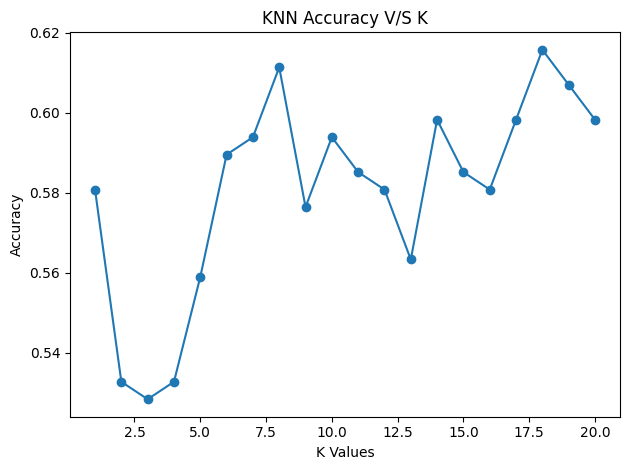

In [22]:
import matplotlib.pyplot as plt

k_values=[]
accuracies=[]

for k in range(1,21):

    model=KNeighborsClassifier(
        n_neighbors=k
    )

    model.fit(X_train,y_train)

    y_pred=model.predict(X_test)

    accuracy=accuracy_score(
        y_test,y_pred
    )

    k_values.append(k)
    accuracies.append(accuracy)

plt.plot(
    k_values,
    accuracies,
    marker="o"
)

plt.xlabel("K Values")
plt.ylabel("Accuracy")
 
plt.title('KNN Accuracy V/S K')

plt.tight_layout()
plt.show()

In [23]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           4       0.00      0.00      0.00         6
           5       0.66      0.74      0.70        96
           6       0.58      0.62      0.60        99
           7       0.31      0.19      0.24        26
           8       0.00      0.00      0.00         2

    accuracy                           0.60       229
   macro avg       0.31      0.31      0.31       229
weighted avg       0.56      0.60      0.58       229



In [24]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

print(confusion_matrix(y_test, y_pred))

print(classification_report(y_test, y_pred))

[[ 0  3  3  0  0]
 [ 0 71 24  1  0]
 [ 0 30 61  8  0]
 [ 0  3 18  5  0]
 [ 0  0  0  2  0]]
              precision    recall  f1-score   support

           4       0.00      0.00      0.00         6
           5       0.66      0.74      0.70        96
           6       0.58      0.62      0.60        99
           7       0.31      0.19      0.24        26
           8       0.00      0.00      0.00         2

    accuracy                           0.60       229
   macro avg       0.31      0.31      0.31       229
weighted avg       0.56      0.60      0.58       229

